# COVID-19 Global Impact & Forecasting Analytics

This notebook explores the report-ready tables generated from the uploaded COVID-19 datasets. It focuses on country-level comparisons, time trends, the forecasting holdout, and US county-level differences. The source workbook currently ends on **20 July 2021**, so the analysis should not be described as a long-term post-pandemic study.

## 1. Load the processed tables

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path('..')
DATA = ROOT / 'data' / 'processed'

country = pd.read_csv(DATA / 'country_impact_summary.csv', parse_dates=['latest_date'])
daily = pd.read_csv(DATA / 'country_daily_covid.csv', parse_dates=['date'])
metrics = pd.read_csv(DATA / 'forecast_model_metrics.csv')
predictions = pd.read_csv(DATA / 'forecast_test_predictions.csv', parse_dates=['date'])
county = pd.read_csv(DATA / 'us_county_impact_summary.csv', parse_dates=['latest_date'])

print(f'{len(daily):,} country-day rows across {daily.location.nunique():,} countries')
print(f"Daily coverage: {daily.date.min().date()} to {daily.date.max().date()}")
print(f'Happiness indicators matched for {country.happiness_score.notna().sum():,} countries')


98,408 country-day rows across 220 countries
Daily coverage: 2020-01-01 to 2021-07-20
Happiness indicators matched for 159 countries


## 2. Country-level burden, adjusted for population

,country,continent,latest_date,cases_per_100k_latest,deaths_per_100k_latest
155,Peru,South America,2021-07-20 00:00:00,"6,352.2",592.2
89,Hungary,Europe,2021-07-20 00:00:00,"8,373.3",310.7
25,Bosnia and Herzegovina,Europe,2021-07-20 00:00:00,"6,258.8",294.7
52,Czechia,Europe,2021-07-20 00:00:00,"15,607.2",283.3
169,San Marino,Europe,2021-07-20 00:00:00,"15,024.5",265.2
147,North Macedonia,Europe,2021-07-20 00:00:00,"7,484.5",263.4
30,Bulgaria,Europe,2021-07-20 00:00:00,"6,090.9",261.7
132,Montenegro,Europe,2021-07-20 00:00:00,"16,042.2",258.4
27,Brazil,South America,2021-07-20 00:00:00,"9,136.0",256.0
42,Colombia,South America,2021-07-20 00:00:00,"9,175.5",230.2


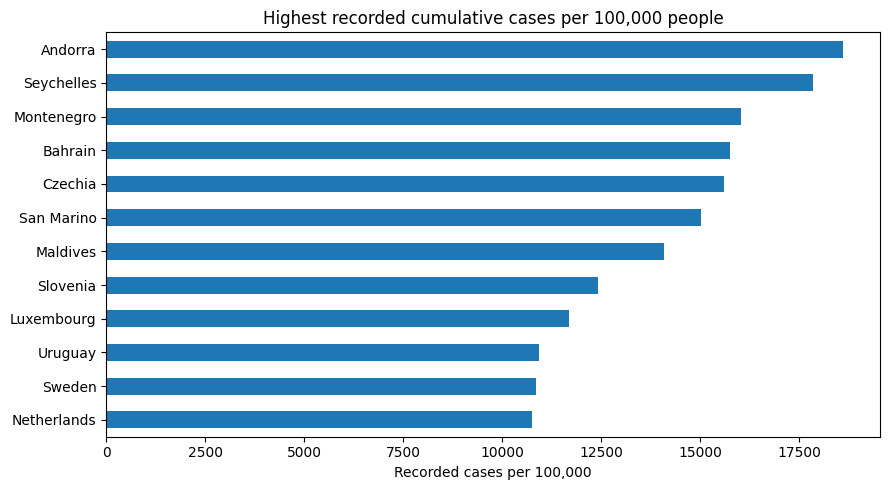

In [2]:
display(country[['country', 'continent', 'latest_date', 'cases_per_100k_latest', 'deaths_per_100k_latest']]
        .dropna(subset=['deaths_per_100k_latest'])
        .sort_values('deaths_per_100k_latest', ascending=False)
        .head(12)
        .style.format({'cases_per_100k_latest':'{:,.1f}', 'deaths_per_100k_latest':'{:,.1f}'}))

plot_data = country.dropna(subset=['cases_per_100k_latest']).nlargest(12, 'cases_per_100k_latest').sort_values('cases_per_100k_latest')
ax = plot_data.plot.barh(x='country', y='cases_per_100k_latest', figsize=(9, 5), legend=False)
ax.set_title('Highest recorded cumulative cases per 100,000 people')
ax.set_xlabel('Recorded cases per 100,000')
ax.set_ylabel('')
plt.tight_layout()
plt.show()


## 3. Global daily trend

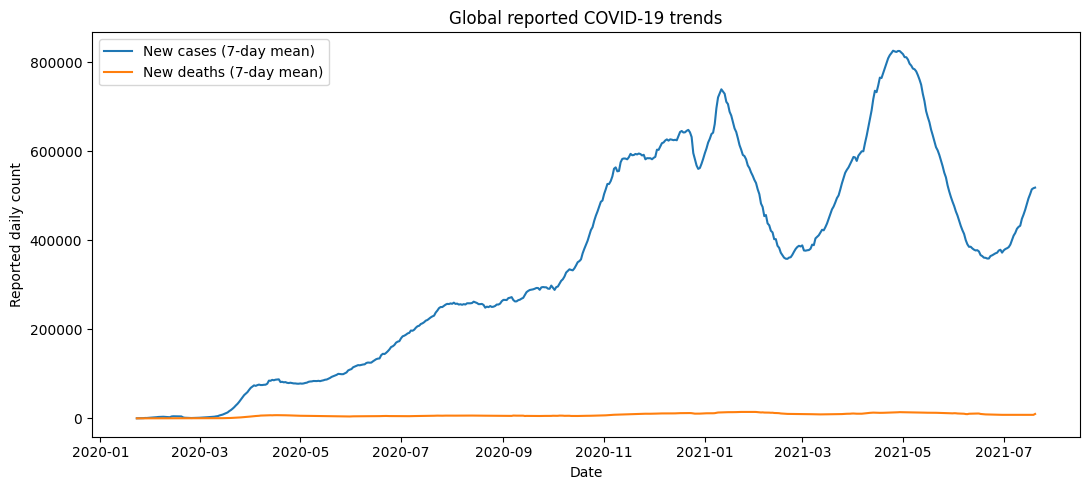

In [3]:
global_daily = (daily.groupby('date', as_index=False)[['new_cases', 'new_deaths']]
                .sum(min_count=1).sort_values('date'))
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(global_daily['date'], global_daily['new_cases'].rolling(7, min_periods=1).mean(), label='New cases (7-day mean)')
ax.plot(global_daily['date'], global_daily['new_deaths'].rolling(7, min_periods=1).mean(), label='New deaths (7-day mean)')
ax.set_title('Global reported COVID-19 trends')
ax.set_xlabel('Date')
ax.set_ylabel('Reported daily count')
ax.legend()
plt.tight_layout()
plt.show()


## 4. Evaluate the forecasting models

,model,MAE,RMSE,R2,train_rows,test_rows,test_start,test_end
0,HistGradientBoosting,14.39,37.34,0.945,88148,4202,2021-06-22,2021-07-13
1,RandomForest,15.62,48.48,0.907,88148,4202,2021-06-22,2021-07-13
2,7-day rolling mean baseline,27.35,69.45,0.810,88148,4202,2021-06-22,2021-07-13


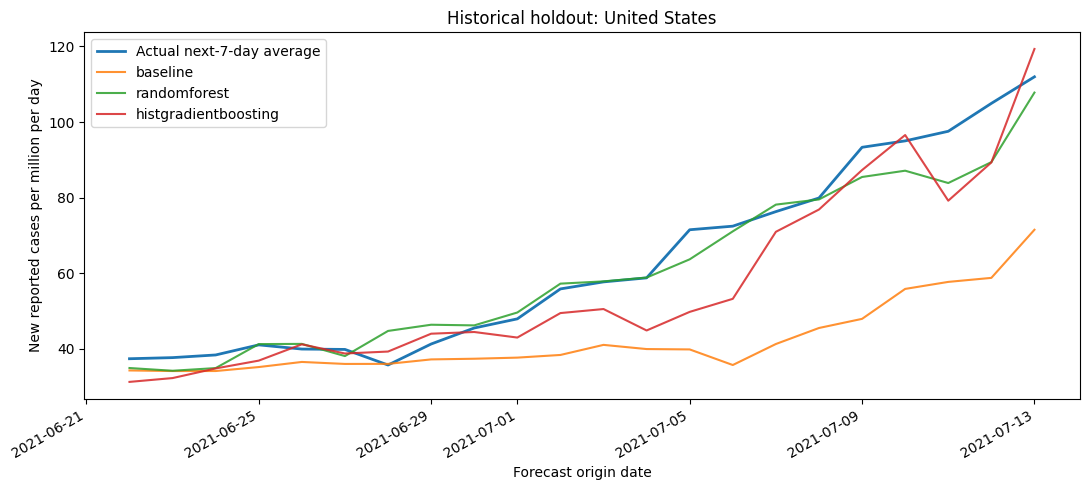

In [4]:
display(metrics.sort_values('MAE').style.format({'MAE':'{:,.2f}', 'RMSE':'{:,.2f}', 'R2':'{:.3f}'}))

# Compare the models on a small sample of countries with many test observations.
country_counts = predictions['location'].value_counts()
example_country = 'United States' if 'United States' in country_counts.index else country_counts.index[0]
example = predictions[predictions['location'] == example_country].sort_values('date')
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(example['date'], example['actual_next_7d_avg_cases_per_million'], label='Actual next-7-day average', linewidth=2)
for col in [c for c in example.columns if c.startswith('prediction_')]:
    ax.plot(example['date'], example[col], label=col.replace('prediction_', '').replace('_', ' '), alpha=.85)
ax.set_title(f'Historical holdout: {example_country}')
ax.set_xlabel('Forecast origin date')
ax.set_ylabel('New reported cases per million per day')
ax.legend()
fig.autofmt_xdate()
plt.tight_layout()
plt.show()


## 5. Happiness and economic context

The happiness scores are pre-pandemic indicators from 2015–2019. The correlation below is descriptive. It does not adjust for age, testing, travel, policy, reporting quality, or epidemic timing, so it must not be interpreted as causal evidence.

,happiness_score,happiness_gdp_component,happiness_health_component,happiness_social_support,happiness_freedom,happiness_corruption_trust,happiness_generosity,cases_per_100k_latest,deaths_per_100k_latest
happiness_score,1.00,0.81,0.78,0.76,0.59,0.42,0.15,0.52,0.36
happiness_gdp_component,0.81,1.00,0.84,0.70,0.38,0.32,-0.02,0.61,0.40
happiness_health_component,0.78,0.84,1.00,0.64,0.37,0.28,0.07,0.58,0.45
happiness_social_support,0.76,0.70,0.64,1.00,0.43,0.19,0.05,0.47,0.37
happiness_freedom,0.59,0.38,0.37,0.43,1.00,0.49,0.34,0.16,0.02
happiness_corruption_trust,0.42,0.32,0.28,0.19,0.49,1.00,0.31,0.03,-0.19
happiness_generosity,0.15,-0.02,0.07,0.05,0.34,0.31,1.00,-0.18,-0.27
cases_per_100k_latest,0.52,0.61,0.58,0.47,0.16,0.03,-0.18,1.00,0.70
deaths_per_100k_latest,0.36,0.40,0.45,0.37,0.02,-0.19,-0.27,0.70,1.00


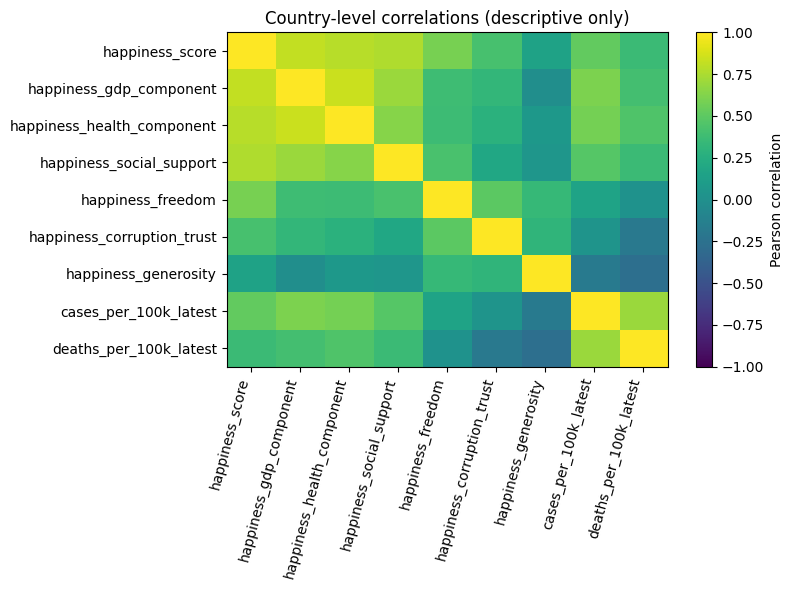

In [5]:
analysis_cols = ['happiness_score', 'happiness_gdp_component', 'happiness_health_component',
                'happiness_social_support', 'happiness_freedom', 'happiness_corruption_trust',
                'happiness_generosity', 'cases_per_100k_latest', 'deaths_per_100k_latest']
analysis_cols = [c for c in analysis_cols if c in country.columns]
corr = country[analysis_cols].corr(numeric_only=True)
display(corr.round(2))

fig, ax = plt.subplots(figsize=(8, 6))
image = ax.imshow(corr, aspect='auto', vmin=-1, vmax=1)
ax.set_xticks(range(len(corr.columns)), corr.columns, rotation=75, ha='right')
ax.set_yticks(range(len(corr.index)), corr.index)
ax.set_title('Country-level correlations (descriptive only)')
fig.colorbar(image, ax=ax, label='Pearson correlation')
plt.tight_layout()
plt.show()


## 6. US county-level comparison

In [6]:
county['Population'] = pd.to_numeric(county.get('Population'), errors='coerce')
county['deaths_per_100k'] = pd.to_numeric(county.get('deaths_per_100k'), errors='coerce')
county_view = county[(county['Population'] >= 100_000) & county['deaths_per_100k'].notna()]
display(county_view.nlargest(10, 'deaths_per_100k')[['Combined_Key', 'Population', 'confirmed_latest', 'deaths_latest', 'cases_per_100k', 'deaths_per_100k']])


,Combined_Key,Population,confirmed_latest,deaths_latest,cases_per_100k,deaths_per_100k
112,"Navajo, Arizona, US",110924,16442,540,14822.761530,486.819805
1904,"Bronx, New York, US",1418207,182479,6569,12866.880505,463.190493
1943,"Queens, New York, US",2253858,276253,9911,12256.894622,439.734890
209,"Imperial, California, US",181215,28722,736,15849.681318,406.147394
1925,"Kings, New York, US",2559903,279526,10392,10919.398118,405.952882
119,"Yuma, Arizona, US",213787,37230,839,17414.529415,392.446688
1891,"San Juan, New Mexico, US",123958,15426,484,12444.537666,390.454831
2730,"Cameron, Texas, US",423163,41221,1647,9741.163571,389.211722
2888,"Potter, Texas, US",117415,17543,456,14941.021164,388.366052
1945,"Richmond, New York, US",476143,74614,1830,15670.502349,384.338319


## Interpretation checklist

- Compare per-capita rates as well as absolute totals.
- Remember that reported cases are affected by testing access and reporting.
- Use time-based evaluation for forecasting and compare against a baseline.
- Treat happiness/economic relationships as associations, not causes.
- The global panel ends 2021-07-20 and the US county snapshot ends 2021-05-29; add later data for longer-term outcomes.